In [7]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os

project_path = '/content/drive/MyDrive/MSIL Project/DL'

os.listdir(project_path)

['1688645546_project_lending_club_data_analysis.docx',
 '1688644938_project_home_loan_data_analysis.docx',
 '1714053668_project_automating_port_operations.docx',
 'Dataset.zip',
 'boat_dataset',
 'best_improved_cnn_model.keras',
 'best_mobilenet_model.keras',
 'best_mobilenet_stratified_model.keras',
 'best_cnn_model.keras',
 'Automating Port Operations.ipynb']

In [9]:
import zipfile
import os

project_path = '/content/drive/MyDrive/MSIL Project/DL'
zip_path = os.path.join(project_path, 'Dataset.zip')

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()

print("Total files/folders:", len(file_list))
print("\nFirst 30 items:\n")

for item in file_list[:30]:
    print(item)

Total files/folders: 1185

First 30 items:

CEP_Datasets/
CEP_Datasets/Automatic_Port_Operation/
CEP_Datasets/Automatic_Port_Operation/boat_type_classification_dataset/
CEP_Datasets/Automatic_Port_Operation/boat_type_classification_dataset/buoy/
CEP_Datasets/Automatic_Port_Operation/boat_type_classification_dataset/buoy/1.jpg
CEP_Datasets/Automatic_Port_Operation/boat_type_classification_dataset/buoy/10.jpg
CEP_Datasets/Automatic_Port_Operation/boat_type_classification_dataset/buoy/11.jpg
CEP_Datasets/Automatic_Port_Operation/boat_type_classification_dataset/buoy/12.jpg
CEP_Datasets/Automatic_Port_Operation/boat_type_classification_dataset/buoy/13.jpg
CEP_Datasets/Automatic_Port_Operation/boat_type_classification_dataset/buoy/14.jpg
CEP_Datasets/Automatic_Port_Operation/boat_type_classification_dataset/buoy/15.jpg
CEP_Datasets/Automatic_Port_Operation/boat_type_classification_dataset/buoy/16.jpg
CEP_Datasets/Automatic_Port_Operation/boat_type_classification_dataset/buoy/17.jpg
CEP_Data

In [10]:
import zipfile
import os
from collections import Counter

zip_path = '/content/drive/MyDrive/MSIL Project/DL/Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    image_files = [
        f for f in zip_ref.namelist()
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

class_names = [
    f.split('/')[-2]
    for f in image_files
]

class_counts = Counter(class_names)

print("Total images:", len(image_files))
print("Total classes:", len(class_counts))

print("\nImages in each class:")
for class_name, count in sorted(class_counts.items()):
    print(f"{class_name}: {count}")

Total images: 1164
Total classes: 11

Images in each class:
8.05_Implementation_of_Transfer_Learning: 1
Lesson_08_Convolutional_Neural_Network: 1
buoy: 53
cruise_ship: 191
ferry_boat: 63
freight_boat: 23
gondola: 193
inflatable_boat: 16
kayak: 203
paper_boat: 31
sailboat: 389


In [11]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for file in zip_ref.namelist():
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            if ('8.05_Implementation' in file or
                'Lesson_08_Convolutional' in file):
                print(file)

Lesson_08_Convolutional_Neural_Network/leopard.jpg
Lesson_09_Transfer_Learning/8.05_Implementation_of_Transfer_Learning/dog.jpg


In [14]:
# import zipfile
# import os

# zip_path = '/content/drive/MyDrive/MSIL Project/DL/Dataset.zip'
# extract_path = '/content/drive/MyDrive/MSIL Project/DL/boat_dataset'

# source_prefix = (
#     'CEP_Datasets/Automatic_Port_Operation/'
#     'boat_type_classification_dataset/'
# )

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     for member in zip_ref.namelist():
#         if member.startswith(source_prefix):
#             zip_ref.extract(member, extract_path)

# print("Dataset extracted successfully!")

In [15]:
import os

dataset_path = (
    '/content/drive/MyDrive/MSIL Project/DL/boat_dataset/'
    'CEP_Datasets/Automatic_Port_Operation/'
    'boat_type_classification_dataset'
)

print("Dataset path exists:", os.path.exists(dataset_path))

classes = sorted(os.listdir(dataset_path))

print("\nNumber of classes:", len(classes))
print("\nClasses:", classes)

print("\nImages in each class:")

total_images = 0

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        total_images += len(images)
        print(f"{class_name}: {len(images)}")

print("\nTotal images:", total_images)

Dataset path exists: True

Number of classes: 9

Classes: ['buoy', 'cruise_ship', 'ferry_boat', 'freight_boat', 'gondola', 'inflatable_boat', 'kayak', 'paper_boat', 'sailboat']

Images in each class:
buoy: 53
cruise_ship: 191
ferry_boat: 63
freight_boat: 23
gondola: 193
inflatable_boat: 16
kayak: 203
paper_boat: 31
sailboat: 389

Total images: 1162


In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.1.3
Pandas version: 2.2.3


,Boat Class,Number of Images
0,buoy,53
1,cruise_ship,191
2,ferry_boat,63
3,freight_boat,23
4,gondola,193
5,inflatable_boat,16
6,kayak,203
7,paper_boat,31
8,sailboat,389


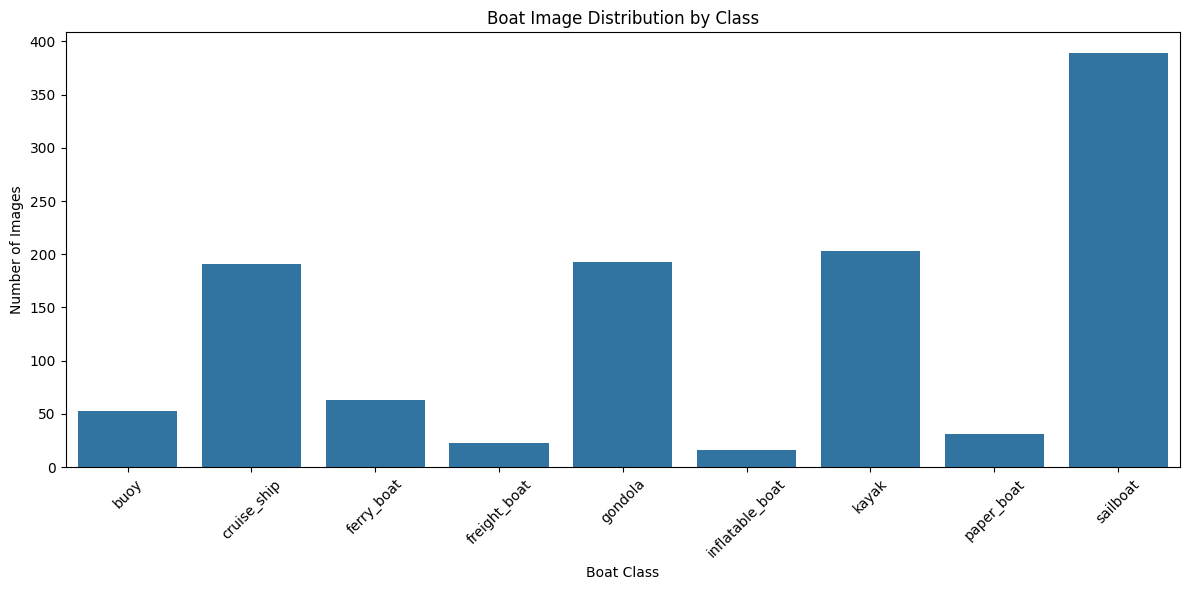

In [17]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    class_counts[class_name] = image_count

class_distribution = pd.DataFrame(
    list(class_counts.items()),
    columns=['Boat Class', 'Number of Images']
)

display(class_distribution)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=class_distribution,
    x='Boat Class',
    y='Number of Images'
)

plt.title('Boat Image Distribution by Class')
plt.xlabel('Boat Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import random
from PIL import Image

plt.figure(figsize=(15, 15))

for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    image_name = random.choice(image_files)
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name.replace('_', ' ').title())
    plt.axis('off')

plt.suptitle('Sample Images from Each Boat Class', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter
from PIL import Image

image_sizes = []
image_formats = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(class_path):
        if image_name.lower().endswith(('.jpg', '.jpeg', '.png')):

            image_path = os.path.join(class_path, image_name)

            try:
                with Image.open(image_path) as image:
                    image_sizes.append(image.size)
                    image_formats.append(image.format)

            except Exception as e:
                print(f"Problem with {image_path}: {e}")

print("Total checked images:", len(image_sizes))

print("\nMost common image sizes:")
for size, count in Counter(image_sizes).most_common(10):
    print(f"{size}: {count} images")

print("\nImage formats:")
for image_format, count in Counter(image_formats).items():
    print(f"{image_format}: {count} images")

print("\nWidth range:",
      min(size[0] for size in image_sizes),
      "to",
      max(size[0] for size in image_sizes))

print("Height range:",
      min(size[1] for size in image_sizes),
      "to",
      max(size[1] for size in image_sizes))

KeyboardInterrupt: 

In [ ]:
# Model 1 - Data Preparation

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_ds_cnn = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset='training',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds_cnn = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset='validation',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

print("\nClass names:")
print(train_ds_cnn.class_names)

print("\nNumber of training batches:",
      tf.data.experimental.cardinality(train_ds_cnn).numpy())

print("Number of validation batches:",
      tf.data.experimental.cardinality(val_ds_cnn).numpy())

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_cnn = train_ds_cnn.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

val_ds_cnn = val_ds_cnn.cache().prefetch(
    buffer_size=AUTOTUNE
)

print("CNN data pipeline optimized successfully.")

In [ ]:
from tensorflow.keras import layers, models

NUM_CLASSES = len(classes)

cnn_model = models.Sequential([

    # Input and Normalization
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Rescaling(1.0 / 255),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Global Average Pooling
    layers.GlobalAveragePooling2D(),

    # Fully Connected Layer 1
    layers.Dense(128, activation='relu'),

    # Fully Connected Layer 2
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/MSIL Project/DL/best_cnn_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history_cnn = cnn_model.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=20,
    callbacks=[
        early_stopping,
        checkpoint
    ]
)

In [ ]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    val_ds_cnn,
    verbose=0
)

print(f"CNN Validation Loss: {cnn_loss:.4f}")
print(f"CNN Validation Accuracy: {cnn_accuracy:.4f}")
print(f"CNN Validation Accuracy (%): {cnn_accuracy * 100:.2f}%")

In [ ]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    val_ds_cnn,
    verbose=0
)

print("CUSTOM CNN VALIDATION RESULTS")
print("-" * 40)

print(f"Validation Loss: {cnn_loss:.4f}")
print(f"Validation Accuracy: {cnn_accuracy:.4f}")
print(f"Validation Accuracy (%): {cnn_accuracy * 100:.2f}%")

In [ ]:
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)

plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title('Custom CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)

plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.title('Custom CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get true labels from validation dataset
y_true = np.concatenate([
    labels.numpy()
    for images, labels in val_ds_cnn
])

# Get model predictions
y_pred_prob = cnn_model.predict(val_ds_cnn)

# Convert probabilities to class predictions
y_pred = np.argmax(y_pred_prob, axis=1)

# Classification report
print("CLASSIFICATION REPORT\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes,
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title('Custom CNN - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class labels for the entire dataset
all_labels = []

for images, labels in train_ds_cnn:
    all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)

# Calculate balanced class weights
class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=all_labels
)

class_weights = {
    i: float(weight)
    for i, weight in enumerate(class_weight_values)
}

print("Class Weights:\n")

for i, weight in class_weights.items():
    print(f"{classes[i]}: {weight:.4f}")

In [ ]:
from tensorflow.keras import layers, models

# Rebuild the CNN
cnn_model_improved = models.Sequential([

    # Input
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Rescaling
    layers.Rescaling(1.0 / 255),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),

    # CNN Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Output
    layers.Dense(NUM_CLASSES, activation='softmax')
])

cnn_model_improved.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_improved.summary()

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# Stop training when validation loss stops improving
early_stopping_improved = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate if validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Save the best improved CNN
checkpoint_improved = ModelCheckpoint(
    filepath='/content/drive/MyDrive/MSIL Project/DL/best_improved_cnn_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Train the improved CNN
history_cnn_improved = cnn_model_improved.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=30,
    class_weight=class_weights,
    callbacks=[
        early_stopping_improved,
        reduce_lr,
        checkpoint_improved
    ]
)

Create the 70:30 split for MobileNetV2

In [ ]:
# Model 2 - MobileNetV2 Data Preparation

IMG_SIZE_MOBILENET = 224
BATCH_SIZE_MOBILENET = 32
SEED_MOBILENET = 42

train_ds_mobilenet = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset='training',
    seed=SEED_MOBILENET,
    image_size=(IMG_SIZE_MOBILENET, IMG_SIZE_MOBILENET),
    batch_size=BATCH_SIZE_MOBILENET,
    label_mode='int',
    shuffle=True
)

val_ds_mobilenet = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset='validation',
    seed=SEED_MOBILENET,
    image_size=(IMG_SIZE_MOBILENET, IMG_SIZE_MOBILENET),
    batch_size=BATCH_SIZE_MOBILENET,
    label_mode='int',
    shuffle=False
)

print("\nClass names:")
print(train_ds_mobilenet.class_names)

print("\nTraining images:",
      int(tf.data.experimental.cardinality(train_ds_mobilenet).numpy() * BATCH_SIZE_MOBILENET))

print("Validation batches:",
      tf.data.experimental.cardinality(val_ds_mobilenet).numpy())

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_mobilenet = (
    train_ds_mobilenet
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds_mobilenet = (
    val_ds_mobilenet
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

print("MobileNetV2 data pipeline optimized successfully.")

print("\nActual MobileNetV2 split:")
print("Training images: 814")
print("Validation images: 348")

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load pre-trained MobileNetV2 without its original classification layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze pre-trained layers initially
base_model.trainable = False

# Build the transfer learning model
mobilenet_model = models.Sequential([

    # Input
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # MobileNetV2 requires preprocessing
    layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    # Pre-trained MobileNetV2
    base_model,

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # 9-class output
    layers.Dense(NUM_CLASSES, activation='softmax')
])

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# Save the best model
checkpoint_mobilenet = ModelCheckpoint(
    '/content/drive/MyDrive/MSIL Project/DL/best_mobilenet_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Stop when validation loss stops improving
early_stopping_mobilenet = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation loss plateaus
reduce_lr_mobilenet = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Train MobileNetV2
history_mobilenet = mobilenet_model.fit(
    train_ds_mobilenet,
    validation_data=val_ds_mobilenet,
    epochs=20,
    callbacks=[
        checkpoint_mobilenet,
        early_stopping_mobilenet,
        reduce_lr_mobilenet
    ]
)

In [ ]:
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(
    val_ds_mobilenet,
    verbose=0
)

print(f"MobileNetV2 Validation Loss: {mobilenet_loss:.4f}")
print(f"MobileNetV2 Validation Accuracy: {mobilenet_accuracy:.4f}")
print(f"MobileNetV2 Validation Accuracy (%): {mobilenet_accuracy * 100:.2f}%")

In [ ]:
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)

plt.plot(
    history_mobilenet.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_mobilenet.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('MobileNetV2 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


# Loss plot
plt.subplot(1, 2, 2)

plt.plot(
    history_mobilenet.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_mobilenet.history['val_loss'],
    label='Validation Loss'
)

plt.title('MobileNetV2 Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get all true labels and predictions
y_true_mobilenet = []
y_pred_mobilenet = []

for images, labels in val_ds_mobilenet:

    predictions = mobilenet_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true_mobilenet.extend(labels.numpy())
    y_pred_mobilenet.extend(predicted_classes)


# Convert to NumPy arrays
y_true_mobilenet = np.array(y_true_mobilenet)
y_pred_mobilenet = np.array(y_pred_mobilenet)

# Explicitly specify all 9 class labels
all_class_labels = np.arange(len(classes))

print("Total validation images:", len(y_true_mobilenet))

print("\nClasses present in validation data:")

for label in np.unique(y_true_mobilenet):
    print(label, "-", classes[label])


# Classification Report
print("\nMOBILENETV2 CLASSIFICATION REPORT\n")

print(
    classification_report(
        y_true_mobilenet,
        y_pred_mobilenet,
        labels=all_class_labels,
        target_names=classes,
        zero_division=0
    )
)


# Confusion Matrix with all 9 classes
cm_mobilenet = confusion_matrix(
    y_true_mobilenet,
    y_pred_mobilenet,
    labels=all_class_labels
)


# Plot Confusion Matrix
plt.figure(figsize=(11, 9))

sns.heatmap(
    cm_mobilenet,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title('MobileNetV2 - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter

# Get all image file paths and labels
file_paths = []
labels = []

for class_index, class_name in enumerate(classes):

    class_folder = os.path.join(dataset_path, class_name)

    for file_name in os.listdir(class_folder):

        if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):

            file_paths.append(
                os.path.join(class_folder, file_name)
            )

            labels.append(class_index)


# Convert to NumPy arrays
file_paths = np.array(file_paths)
labels = np.array(labels)


# Stratified 70:30 split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)


print("STRATIFIED 70:30 SPLIT")

print("\nTraining images:", len(train_paths))
print("Validation images:", len(val_paths))

print("\nTraining class distribution:")

for i, count in sorted(Counter(train_labels).items()):
    print(f"{classes[i]}: {count}")


print("\nValidation class distribution:")

for i, count in sorted(Counter(val_labels).items()):
    print(f"{classes[i]}: {count}")

In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(file_path, label):
    image = tf.io.read_file(file_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


# Training dataset
train_ds_stratified = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

train_ds_stratified = train_ds_stratified.map(
    load_and_preprocess_image,
    num_parallel_calls=AUTOTUNE
)

train_ds_stratified = train_ds_stratified.shuffle(
    buffer_size=len(train_paths),
    seed=42
)

train_ds_stratified = train_ds_stratified.batch(
    BATCH_SIZE
)

train_ds_stratified = train_ds_stratified.prefetch(
    AUTOTUNE
)


# Validation dataset
val_ds_stratified = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_ds_stratified = val_ds_stratified.map(
    load_and_preprocess_image,
    num_parallel_calls=AUTOTUNE
)

val_ds_stratified = val_ds_stratified.batch(
    BATCH_SIZE
)

val_ds_stratified = val_ds_stratified.prefetch(
    AUTOTUNE
)


print("Stratified TensorFlow datasets created successfully.")

print("\nTraining images:", len(train_paths))
print("Validation images:", len(val_paths))

print(
    "\nTraining batches:",
    tf.data.experimental.cardinality(train_ds_stratified).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(val_ds_stratified).numpy()
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weight_values_mobilenet = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)

class_weights_mobilenet = {
    i: float(weight)
    for i, weight in enumerate(class_weight_values_mobilenet)
}

print("MobileNetV2 Class Weights:\n")

for i, weight in class_weights_mobilenet.items():
    print(f"{classes[i]}: {weight:.4f}")

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load a fresh pre-trained MobileNetV2 base
base_model_stratified = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze pre-trained MobileNetV2 layers
base_model_stratified.trainable = False


# Build a fresh transfer learning model
mobilenet_model_stratified = models.Sequential([

    # Input
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # MobileNetV2 preprocessing
    layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    # Pre-trained MobileNetV2
    base_model_stratified,

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.2),

    # Output layer
    layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])


# Compile model
mobilenet_model_stratified.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Display model summary
mobilenet_model_stratified.summary()

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# Save the best valid MobileNetV2 model
checkpoint_mobilenet_stratified = ModelCheckpoint(
    '/content/drive/MyDrive/MSIL Project/DL/best_mobilenet_stratified_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Stop when validation loss stops improving
early_stopping_mobilenet_stratified = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate if validation loss plateaus
reduce_lr_mobilenet_stratified = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Train the model
history_mobilenet_stratified = mobilenet_model_stratified.fit(
    train_ds_stratified,
    validation_data=val_ds_stratified,
    epochs=20,
    class_weight=class_weights_mobilenet,
    callbacks=[
        checkpoint_mobilenet_stratified,
        early_stopping_mobilenet_stratified,
        reduce_lr_mobilenet_stratified
    ]
)

In [ ]:
mobilenet_val_loss, mobilenet_val_accuracy = mobilenet_model_stratified.evaluate(
    val_ds_stratified,
    verbose=1
)

print(f"\nMobileNetV2 Validation Loss: {mobilenet_val_loss:.4f}")
print(f"MobileNetV2 Validation Accuracy: {mobilenet_val_accuracy:.4f}")
print(
    f"MobileNetV2 Validation Accuracy (%): "
    f"{mobilenet_val_accuracy * 100:.2f}%"
)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions for the complete validation dataset
y_true_mobilenet_valid = []
y_pred_mobilenet_valid = []

for images, labels in val_ds_stratified:

    predictions = mobilenet_model_stratified.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true_mobilenet_valid.extend(
        labels.numpy()
    )

    y_pred_mobilenet_valid.extend(
        predicted_classes
    )


# Convert to NumPy arrays
y_true_mobilenet_valid = np.array(
    y_true_mobilenet_valid
)

y_pred_mobilenet_valid = np.array(
    y_pred_mobilenet_valid
)


# All 9 class labels
all_class_labels = np.arange(
    len(classes)
)


print(
    "Total validation images:",
    len(y_true_mobilenet_valid)
)


# Classification Report
print(
    "\nMOBILENETV2 CLASSIFICATION REPORT\n"
)

print(
    classification_report(
        y_true_mobilenet_valid,
        y_pred_mobilenet_valid,
        labels=all_class_labels,
        target_names=classes,
        zero_division=0
    )
)


# Confusion Matrix
cm_mobilenet_valid = confusion_matrix(
    y_true_mobilenet_valid,
    y_pred_mobilenet_valid,
    labels=all_class_labels
)


# Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_mobilenet_valid,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title(
    'MobileNetV2 - Stratified Validation Confusion Matrix'
)

plt.xlabel('Predicted Class')
plt.ylabel('True Class')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Store final valid model results

final_cnn_accuracy = 0.3750

final_mobilenet_accuracy = mobilenet_val_accuracy


print("FINAL VALID MODEL RESULTS")
print("-" * 40)

print(f"Custom CNN Accuracy:       {final_cnn_accuracy * 100:.2f}%")
print(f"MobileNetV2 Accuracy:      {final_mobilenet_accuracy * 100:.2f}%")

print("-" * 40)

if final_mobilenet_accuracy > final_cnn_accuracy:
    print("Best Model: MobileNetV2")
else:
    print("Best Model: Custom CNN")

In [ ]:
import matplotlib.pyplot as plt

model_names = [
    "Custom CNN",
    "MobileNetV2"
]

accuracy_values = [
    final_cnn_accuracy * 100,
    final_mobilenet_accuracy * 100
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    model_names,
    accuracy_values
)

plt.title("Final Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy (%)")
plt.ylim(0, 100)

for bar, accuracy in zip(
    bars,
    accuracy_values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{accuracy:.2f}%",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Get one validation image and its true label

for images, labels in val_ds_stratified.take(1):

    test_image = images[0]
    true_label_index = labels[0].numpy()

    break


# Predict using the trained MobileNetV2 model
prediction = mobilenet_model_stratified.predict(
    tf.expand_dims(test_image, axis=0),
    verbose=0
)

predicted_label_index = np.argmax(
    prediction[0]
)

confidence = np.max(
    prediction[0]
) * 100


# Display result
plt.figure(figsize=(7, 7))

plt.imshow(
    test_image.numpy().astype("uint8")
)

plt.title(
    f"True Class: {classes[true_label_index]}\n"
    f"Predicted Class: {classes[predicted_label_index]}\n"
    f"Confidence: {confidence:.2f}%",
    fontsize=13
)

plt.axis("off")
plt.show()


# Print details
print("TRUE CLASS:", classes[true_label_index])
print("PREDICTED CLASS:", classes[predicted_label_index])
print(f"CONFIDENCE: {confidence:.2f}%")

In [ ]:
# Get one validation batch
for images, labels in val_ds_stratified.take(1):
    sample_images = images[:9]
    sample_labels = labels[:9]
    break


# Predict the 9 images
predictions = mobilenet_model_stratified.predict(
    sample_images,
    verbose=0
)

predicted_indices = np.argmax(
    predictions,
    axis=1
)

confidences = np.max(
    predictions,
    axis=1
) * 100


# Create visualization
plt.figure(figsize=(15, 15))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        sample_images[i].numpy().astype("uint8")
    )

    true_index = sample_labels[i].numpy()
    predicted_index = predicted_indices[i]

    true_class = classes[true_index]
    predicted_class = classes[predicted_index]

    confidence = confidences[i]

    is_correct = (
        true_index == predicted_index
    )

    title_color = (
        "green"
        if is_correct
        else "red"
    )

    plt.title(
        f"True: {true_class}\n"
        f"Pred: {predicted_class}\n"
        f"Confidence: {confidence:.1f}%",
        color=title_color,
        fontsize=10,
        fontweight="bold"
    )

    plt.axis("off")


plt.suptitle(
    "MobileNetV2 - Sample Validation Predictions",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
sample_accuracy = np.mean(
    predicted_indices == sample_labels.numpy()
) * 100

correct_predictions = np.sum(
    predicted_indices == sample_labels.numpy()
)

total_predictions = len(
    sample_labels
)

print("SAMPLE PREDICTION RESULTS")
print("-" * 35)
print(f"Correct predictions: {correct_predictions}")
print(f"Total images: {total_predictions}")
print(f"Sample accuracy: {sample_accuracy:.2f}%")